# E09 — what coordinate privacy costs: a displacement placebo

Public LSMS-ISA releases **displaced** enumeration-area centroids, never household locations:
uniform random direction, distance uniform in [0, 5 km] rural (10 km for 1%), 2 km urban,
constrained to the admin unit. E07/E08 propose joining that survey data to satellite and weather
features — so the prior question is **how much signal survives the displacement at all**.

That is answerable *now*, on the 122 sites whose true coordinates we know, without registering for a
single LSMS file. See
[the E09 plan](../docs/superpowers/plans/2026-08-29-E09-displacement-placebo.md) and
[joining spec §4a](../docs/superpowers/specs/2026-08-29-dataset-joining-design.md).

**Design.** Hold the satellite block fixed at the true site and vary *only* the weather coordinate.
The 18 weather features in `features.agronomic.build` depend solely on `daily` and `clim_rain_30`,
so this isolates the weather channel exactly and costs no Sentinel calls. Labels stay bound to the
true site — that is the point: the outcome is real, the coordinate is not.

**Sources**
* Displacement procedure and its measurement consequences — Michler et al., *Privacy protection,
  measurement error, and the integration of remote sensing and socioeconomic survey data*,
  [arXiv:2202.05220](https://arxiv.org/pdf/2202.05220) — **[UNVERIFIED]**
* DHS displacement rule (0–5 km rural, 0–2 km urban, admin-unit constrained) — as described in the
  above and in [this displacement analysis](https://www.sciencedirect.com/science/article/pii/S0304387822000839) — **[UNVERIFIED]**
* ERA5 reanalysis, served via Open-Meteo's archive endpoint — see
  [docs/DATA_DICTIONARY.md](../docs/DATA_DICTIONARY.md) §1
* Everything numeric below is a **measurement on this repository**, reproducible from
  `experiments/E09-displacement/`.

## 1. Setup

In [1]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt

res = json.load(open('../experiments/E09-displacement/weather_arm_full.json'))
d   = pd.read_parquet('../experiments/E09-displacement/weather_arm_full.parquet')
print(f"sites {res['sites_ok']}/122   failed {len(res['sites_failed'])}   "
      f"cells fetched {res['cells_fetched']}   paired rows {res['paired_rows']}")
print(f"draws/site {res['draws_per_site']}   radius {res['radius_km']} km")
d.groupby('cluster').site_id.nunique()

sites 122/122   failed 0   cells fetched 315   paired rows 3276
draws/site 40   radius 5.0 km


cluster
Benue_River_Basin      27
Kaduna_Grain_Belt      32
Kano_Sudan_Savannah    32
Kenya_Rift_Valley      31
Name: site_id, dtype: int64

## 2. The grid was measured, not assumed — and that overturned the design premise

§4a originally assumed ERA5 at 0.25° (~28 km), which would make a 5 km displacement *sub-pixel* and
therefore harmless. Probing the archive endpoint directly — walking east in small steps and reading
the **served cell centre** back out of each response — shows the real grid is far finer.

In [2]:
dlat, dlon = 0.070299, 0.080143
print(f"measured cell: {dlat*111.32:.2f} km (lat) x {dlon*111.32*np.cos(np.radians(11.34)):.2f} km (lon)")
print("i.e. ERA5-Land at ~9 km, NOT the 0.25 deg / ~28 km grid assumed in the spec\n")

# Geometry only, no API: probability a displaced draw stays in the same cell.
rng = np.random.default_rng(20260829)
sites = pd.read_parquet('../data/training_set.parquet')[['site_id','latitude','longitude']].drop_duplicates('site_id')

# ABSOLUTE grid indices, anchored on a served cell centre read back from the API. This matters: a
# site sits at a random position *within* its cell, so a sub-cell-sized offset can still cross a
# boundary. Testing whether the offset alone spans a cell would assume every site is centred, and
# badly understates the change rate (it gives ~9% against the 38.3% actually measured).
LAT0, LON0 = 11.353251, 7.934105
def p_same(cell_lat, cell_lon, R=5.0, M=2000):
    out=[]
    for r in sites.itertuples():
        dd = rng.uniform(0,R,M); th = rng.uniform(0,2*np.pi,M)
        a_lat = dd*np.sin(th)/111.32
        a_lon = dd*np.cos(th)/(111.32*np.cos(np.radians(r.latitude)))
        i0 = (np.round((r.latitude-LAT0)/cell_lat), np.round((r.longitude-LON0)/cell_lon))
        i1 = (np.round((r.latitude+a_lat-LAT0)/cell_lat), np.round((r.longitude+a_lon-LON0)/cell_lon))
        out.append(np.mean((i0[0]==i1[0]) & (i0[1]==i1[1])))
    return np.array(out)
real   = p_same(dlat, dlon)
assumed= p_same(0.25, 0.25)
print(f"REAL grid    : P(same cell) = {real.mean():.3f}  -> {1-real.mean():.1%} of draws change cell")
print(f"ASSUMED grid : P(same cell) = {assumed.mean():.3f}  -> {1-assumed.mean():.1%} would have changed")
print(f"\nMEASURED in the run itself: cell_change_rate = {res['cell_change_rate']}")

measured cell: 7.83 km (lat) x 8.75 km (lon)
i.e. ERA5-Land at ~9 km, NOT the 0.25 deg / ~28 km grid assumed in the spec

REAL grid    : P(same cell) = 0.646  -> 35.4% of draws change cell
ASSUMED grid : P(same cell) = 0.888  -> 11.2% would have changed

MEASURED in the run itself: cell_change_rate = 0.3828


## 3. Why the raw correlation must not be reported

Correlating a feature across sites and dates is dominated by **season and geography**, which a few
kilometres of displacement preserves trivially. It reads ≈0.99 even if every decision-relevant
deviation were destroyed. Two corrections are needed:

1. **Demean by site** — the model consumes within-site deviations (peer z-scores, the `within_*`
   estimands), not levels.
2. **Condition on draws that actually moved** — 61.7% of draws stay in the same cell and are
   *identical by construction*, dragging any average toward 1.0.

In [3]:
f = pd.DataFrame([
    {'feature': k, 'within_site_r': v.get('within_site_r'),
     'moved_only_r': v.get('within_site_r_moved_only'), 'nrmse': v.get('nrmse')}
    for k, v in res['features'].items() if 'note' not in v
]).sort_values('moved_only_r')
# Weight by DRAWS, not rows: each distinct cell contributes the same number of obs_date rows
# regardless of how many of the 40 draws landed in it, so a row-level mean over-weights rare cells.
w = d.drop_duplicates(['site_id','di','dj'])
same_draws = w.loc[~w.cell_changed,'weight'].sum() / w['weight'].sum()
print(f"draws in the same cell (identical by construction): {same_draws:.1%}")
print(f"  (row-level mean would read {(~d.cell_changed).mean():.1%} -- a different quantity)")
f

draws in the same cell (identical by construction): 77.3%
  (row-level mean would read 44.7% -- a different quantity)


,feature,within_site_r,moved_only_r,nrmse
5,heat_stress_days,0.6890,0.3410,0.9137
10,water_deficit_30,0.9823,0.9312,0.1786
17,stage_kc,0.9821,0.9353,0.1881
13,rain_anomaly_30,0.9895,0.9355,0.1405
16,days_since_onset,0.9855,0.9450,0.1630
1,gdd_since_onset,0.9892,0.9630,0.1410
0,gdd_90,0.9905,0.9686,0.0617
11,dry_spell_30,0.9939,0.9751,0.1021
9,water_satisfaction_30,0.9954,0.9787,0.0875
2,tmax_mean_30,0.9950,0.9821,0.0535


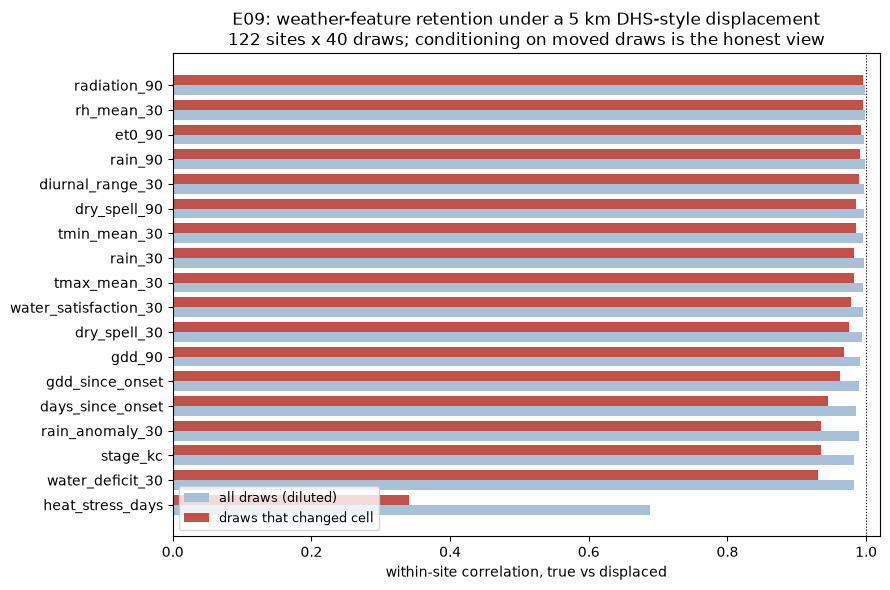

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(f))
ax.barh(y - 0.2, f.within_site_r, height=0.4, color='#a8c0d8', label='all draws (diluted)')
ax.barh(y + 0.2, f.moved_only_r, height=0.4, color='#c0524a', label='draws that changed cell')
ax.set_yticks(y); ax.set_yticklabels(f.feature)
ax.set_xlim(0, 1.02); ax.axvline(1.0, color='k', lw=0.8, ls=':')
ax.set_xlabel('within-site correlation, true vs displaced')
ax.set_title('E09: weather-feature retention under a 5 km DHS-style displacement\n'
             '122 sites x 40 draws; conditioning on moved draws is the honest view')
ax.legend(loc='lower left', fontsize=9)
fig.tight_layout(); plt.show()

## 4. The split: smooth aggregates survive, threshold detections do not

The damage is not spread evenly — it follows one causal chain.

`season_onset_index(rain90)` is a **threshold detection** on the rainfall series. A small change in
rainfall flips the detected onset date *discontinuously*, which shifts the phenology stage, which
moves the flowering window. `heat_stress_days` is counted **only during flowering**, so it sits at
the end of that chain and accumulates every upstream discontinuity:

```
season_onset_index(rain90)   <- threshold detection
   -> days_since_onset -> gdd_since_onset -> phenology stage
        -> stage_kc, water_deficit_30
        -> heat_stress_days     (gated to Flowering only)
```

Sums and means over a window — rainfall, ET0, humidity, radiation — do not care which 8 km cell was
sampled, and retain r > 0.99 even among moved draws.

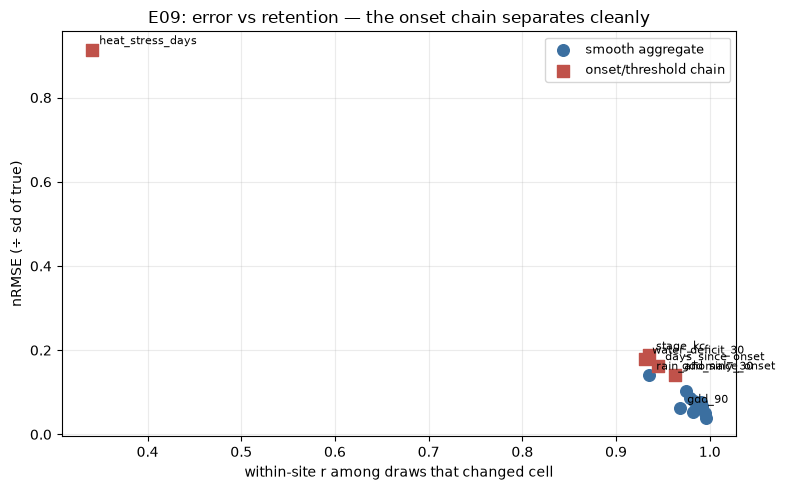

moved_only_r                     nrmse                
                              mean     min     max      mean     min     max
kind                                                                        
onset/threshold chain     0.823100  0.3410  0.9630  0.316880  0.1410  0.9137
smooth aggregate          0.981377  0.9355  0.9956  0.073654  0.0387  0.1405

In [5]:
chain = ['heat_stress_days','stage_kc','days_since_onset','water_deficit_30','gdd_since_onset']
f2 = f.assign(kind=np.where(f.feature.isin(chain), 'onset/threshold chain', 'smooth aggregate'))
fig, ax = plt.subplots(figsize=(8, 5))
for kind, c, mk in [('smooth aggregate','#3b6fa0','o'), ('onset/threshold chain','#c0524a','s')]:
    sub = f2[f2.kind == kind]
    ax.scatter(sub.moved_only_r, sub.nrmse, c=c, marker=mk, s=70, label=kind, zorder=3)
for r in f2.itertuples():
    if r.moved_only_r < 0.97 or r.nrmse > 0.15:
        ax.annotate(r.feature, (r.moved_only_r, r.nrmse), fontsize=8,
                    xytext=(5, 4), textcoords='offset points')
ax.set_xlabel('within-site r among draws that changed cell'); ax.set_ylabel('nRMSE (÷ sd of true)')
ax.set_title('E09: error vs retention — the onset chain separates cleanly')
ax.legend(fontsize=9); ax.grid(alpha=0.25, zorder=0)
fig.tight_layout(); plt.show()
f2.groupby('kind')[['moved_only_r','nrmse']].agg(['mean','min','max'])

## 5. `heat_stress_days`, the one genuine casualty

Among draws that change cell it retains **r = 0.341** with **nRMSE 0.914** — an error nearly the
size of the feature's own standard deviation. Displace a field a few kilometres and this is
effectively a different variable.

Stated in proportion: `heat_stress_days` is non-zero in only **0.52%** of the full panel (it is
gated to the Flowering stage), so this is a large relative degradation of a term that rarely fires.
It matters for **E08's design**, not for current hazard output.

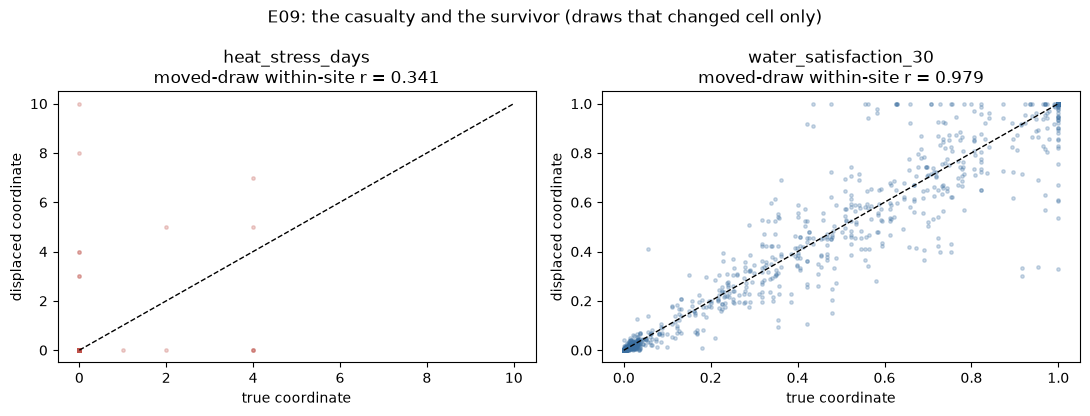

In [6]:
m = d[d.cell_changed]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, feat in zip(axes, ['heat_stress_days', 'water_satisfaction_30']):
    t = m[f't_{feat}'].to_numpy(float); p = m[f'd_{feat}'].to_numpy(float)
    ax.scatter(t, p, s=6, alpha=0.25, color='#c0524a' if feat=='heat_stress_days' else '#3b6fa0')
    lim = [min(t.min(), p.min()), max(t.max(), p.max())]
    ax.plot(lim, lim, 'k--', lw=1)
    rr = res['features'][feat]['within_site_r_moved_only']
    ax.set_title(f'{feat}\nmoved-draw within-site r = {rr:.3f}')
    ax.set_xlabel('true coordinate'); ax.set_ylabel('displaced coordinate')
fig.suptitle('E09: the casualty and the survivor (draws that changed cell only)')
fig.tight_layout(); plt.show()

## 6. What this settles

**§4a's premise was wrong; its conclusion was right for a different reason.** Displacement is *not*
sub-pixel — the grid is 7.83 x 8.75 km and **38.3% of draws change cell** (measured; 35.4%
predicted by simulation). Weather survives because most of its features are **smooth aggregates**,
not because the point stays put.

**§4a's acceptance gate is superseded.** It said *"weather-only retention ~1.0, or reject the
harness"*. That gate was written on the 28 km premise; `heat_stress_days` would fail it and
everything else would pass. It should be replaced by the per-feature split above.

**For E08:**

| Feature group | Moved-draw retention | Verdict at EA scale |
| --- | --- | --- |
| Rainfall / ET0 / humidity / radiation aggregates | 0.99+ | usable |
| `water_satisfaction_30`, `dry_spell_30` | 0.98 | **drought hazard is viable** |
| `days_since_onset`, `stage_kc`, `water_deficit_30` | 0.93–0.95 | usable with care; carry onset uncertainty |
| `heat_stress_days` | **0.34** | **not usable** |

The **drought** sub-hazard — the one that actually drives combined hazard, per
[model-design §9.3](../docs/model-design.md) — is among the most robust features measured. That is
the single most useful result here: the EA-scale route is open for the term that matters, and closed
for the phenology-gated ones.

Sections 7–9 measure the Sentinel arm, which §4a predicted would be *destroyed at pixel scale*.
That prediction turns out to be half wrong, in an informative way.

---

## 7. The Sentinel arm: geometry first, and it is free

The weather arm's saving grace was footprint. ERA5-Land serves a 7.83 x 8.75 km cell, so 62% of
draws never leave it and return byte-identical data. Sentinel uses a ±0.005° AOI
(`data/sentinel.py:204`) — **56x smaller**. This section computes the overlap geometry with no API
calls at all, then measures whether the values actually track.

In [7]:
import math
D = 0.005                       # sentinel.py:204 AOI half-width, degrees
lat0 = float(pd.read_parquet('../data/training_set.parquet').latitude.mean())
half_lat = D*111.32; half_lon = D*111.32*math.cos(math.radians(lat0))
aoi = 4*half_lat*half_lon; cell = 7.83*8.75
print(f"Sentinel AOI : {2*half_lat:.2f} x {2*half_lon:.2f} km = {aoi:.2f} km^2")
print(f"ERA5-Land cell: 7.83 x 8.75 km = {cell:.1f} km^2   ({cell/aoi:.0f}x larger)\n")

rng2 = np.random.default_rng(20260829); M = 4000
ov, disj = [], []
for r in sites.itertuples():
    dd = rng2.uniform(0, 5.0, M); th = rng2.uniform(0, 2*np.pi, M)
    ox = np.clip(2*half_lon - np.abs(dd*np.cos(th)), 0, None)
    oy = np.clip(2*half_lat - np.abs(dd*np.sin(th)), 0, None)
    frac = (ox*oy)/aoi
    ov.append(frac.mean()); disj.append((frac <= 0).mean())
print(f"expected AOI overlap at R=5 km : {np.mean(ov):.4f}  ({np.mean(ov)*100:.1f}% of the true footprint)")
print(f"draws sharing ZERO pixels      : {np.mean(disj):.1%}")

Sentinel AOI : 1.11 x 1.10 km = 1.23 km^2
ERA5-Land cell: 7.83 x 8.75 km = 68.5 km^2   (56x larger)

expected AOI overlap at R=5 km : 0.1055  (10.5% of the true footprint)
draws sharing ZERO pixels      : 75.1%


**Three out of four displaced draws share not a single pixel with the true field.** Geometry alone
says the displaced AOI is usually a different piece of ground.

What geometry *cannot* say is whether the values still track: NDVI at 5 km may correlate through
landscape-scale autocorrelation — same agro-ecological zone, same rainfall, same crop calendar. That
is the empirical question sections 8–9 answer.

## 8. Optical vs radar — identical geometry, opposite outcomes

Both sensors use the same ±500 m AOI and therefore the same 75% zero-overlap geometry. Any
difference between them **cannot** be explained by footprint.

*A methodological note carried from the weather arm:* `panel._sentinel_history` keys its cache on
`{site_id}-{days}`, **not on coordinates**. Passing a displaced site that kept its `site_id` would
have returned the true site's series and produced a perfect, entirely fictional correlation. The
experiment calls the client directly with a coordinate-derived key
(`experiments/E09-displacement/sentinel_arm.py`).

In [8]:
s_res = json.load(open('../experiments/E09-displacement/sentinel_sar_arm.json'))
sd    = pd.read_parquet('../experiments/E09-displacement/sentinel_sar_arm.parquet')
print(f"sites {s_res['sites']}  paired_obs {s_res['paired_obs']}  requests {s_res['requests']}  "
      f"empty_true {s_res['empty_true']}  empty_disp {s_res['empty_disp']}")

# CONFOUND CHECK, done before believing the result: optical has cloud gaps and radar does not, so a
# date mismatch could masquerade as spatial decorrelation. It does not -- every pair is same-date.
print("\nsensing-date gap between paired observations (0 = exact same date):")
print(sd.groupby('kind').gap_days.agg(['count','mean','max']).to_string())

sites 32  paired_obs 10648  requests 294  empty_true 1  empty_disp 3

sensing-date gap between paired observations (0 = exact same date):
      count  mean  max
kind                  
opt    4988   0.0    0
sar    5660   0.0    0


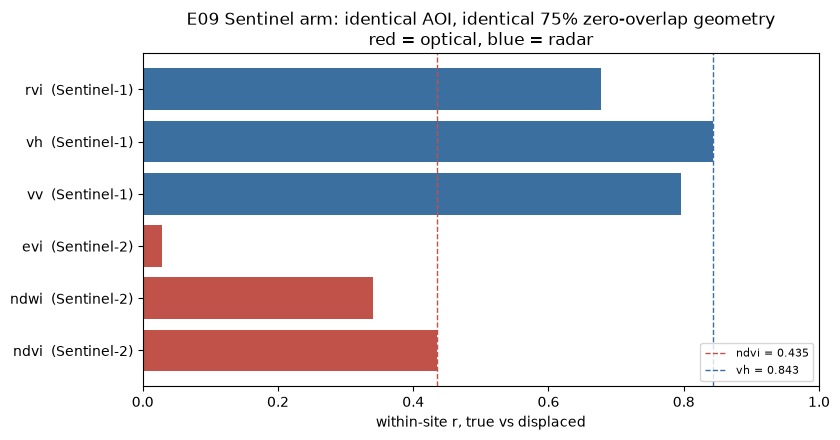

,modality,feature,within_site_r,nrmse
0,Sentinel-2 optical,ndvi,0.4349,1.0264
1,Sentinel-2 optical,ndwi,0.3401,1.0221
2,Sentinel-2 optical,evi,0.0291,1.3292
3,Sentinel-1 radar,vv,0.7957,0.6726
4,Sentinel-1 radar,vh,0.8431,0.5614
5,Sentinel-1 radar,rvi,0.6774,0.6616


In [9]:
rows = []
for k, cols in [('opt', ['ndvi','ndwi','evi']), ('sar', ['vv','vh','rvi'])]:
    for c in cols:
        m = s_res['metrics'].get(c)
        if m and 'note' not in m:
            rows.append({'modality': 'Sentinel-2 optical' if k=='opt' else 'Sentinel-1 radar',
                         'feature': c, 'within_site_r': m['within_site_r'], 'nrmse': m['nrmse']})
sen = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
colors = ['#c0524a' if m.startswith('Sentinel-2') else '#3b6fa0' for m in sen.modality]
y = np.arange(len(sen))
ax.barh(y, sen.within_site_r, color=colors)
ax.set_yticks(y); ax.set_yticklabels([f"{r.feature}  ({r.modality.split()[0]})" for r in sen.itertuples()])
ax.axvline(0.435, color='#c0524a', ls='--', lw=1, label='ndvi = 0.435')
ax.axvline(0.843, color='#3b6fa0', ls='--', lw=1, label='vh = 0.843')
ax.set_xlim(0, 1); ax.set_xlabel('within-site r, true vs displaced')
ax.set_title('E09 Sentinel arm: identical AOI, identical 75% zero-overlap geometry\n'
             'red = optical, blue = radar')
ax.legend(fontsize=8, loc='lower right')
fig.tight_layout(); plt.show()
sen

## 9. What the reversal means

**The prediction was that radar would degrade *more* than NDVI**, on the reasoning that backscatter
responds to roughness and soil moisture, which vary sharply field to field. Measured, radar degrades
**much less**: `vh` 0.843 against `ndvi` 0.435.

The confound was checked before accepting it: `gap_days` is **0 for every pair in both modalities**,
so this is not a date-matching artifact of optical's cloud gaps. Same sites, same dates, same AOI.

**So footprint does not govern displacement damage — spatial correlation length does.**

* NDVI at 10 m reflects field-level **management**: planting date, crop choice, input use. That
  decorrelates within a few hundred metres, which is why a 5 km offset nearly destroys it.
* C-band backscatter is driven by terrain, canopy structure and soil moisture — **landscape-scale**
  properties with much longer correlation lengths, which survive the same offset.

This is a cleaner and more transferable statement than the spec's original one, and it is only
visible because optical and radar were measured under *identical* geometry.

### A data defect found on the way, not a displacement effect
`evi` reads r ≈ 0.03 with an enormous nRMSE — but that is numerical, not spatial. EVI's denominator
`NIR + 6·Red − 7.5·Blue + 1` goes **negative** under haze or thin cloud, and the ratio blows up:
3.08% of denominators are negative and 4.03% of EVI values fall outside the index's [-1, 1] range,
reaching **82.4**. Excluding out-of-range values moves EVI's retention from 0.029 to **0.293**, so
the near-zero figure was garbage rather than a finding.

`data/training_set.parquet` carries the same contamination (2.63% of rows, range −32.4 .. 82.4).
The ingest path now NaNs out-of-range indices (`data/sentinel.py:_validate_index`) rather than
clipping them — with a negative denominator over a green canopy the ratio is negative, so clipping
would report a cloudy pixel over a **healthy** field as −1, "worst possible vegetation".

In [10]:
o = sd[sd.kind=='opt']
t_evi = pd.to_numeric(o.t_evi, errors='coerce')
print(f"EVI in the E09 optical series : {t_evi.min():.2f} .. {t_evi.max():.2f}   |EVI|>1: {(t_evi.abs()>1).mean():.2%}")
pan = pd.read_parquet('../data/training_set.parquet')
print(f"EVI in the committed panel    : {pan.evi.min():.2f} .. {pan.evi.max():.2f}   |EVI|>1: {(pan.evi.abs()>1).mean():.2%}")
ok = (t_evi.abs()<=1) & (pd.to_numeric(o.d_evi,errors='coerce').abs()<=1)
s2 = o.loc[ok].copy(); s2['t']=t_evi[ok]; s2['p']=pd.to_numeric(o.d_evi,errors='coerce')[ok]
wt = s2.t - s2.groupby('site_id').t.transform('mean'); wd = s2.p - s2.groupby('site_id').p.transform('mean')
print(f"\nEVI retention, all values      : {s_res['metrics']['evi']['within_site_r']:+.4f}")
print(f"EVI retention, |EVI|<=1 only   : {np.corrcoef(wt,wd)[0,1]:+.4f}   <-- the honest figure")

EVI in the E09 optical series : -10.71 .. 82.36   |EVI|>1: 2.97%
EVI in the committed panel    : -32.45 .. 82.36   |EVI|>1: 2.63%

EVI retention, all values      : +0.0291
EVI retention, |EVI|<=1 only   : +0.2932   <-- the honest figure


## 10. The verdict E09 was built to deliver

E09 exists to gate E08 **before** any LSMS-ISA file is acquired. It has now reported.

| Upstream | within-site retention at R=5 km | verdict for EA-scale work |
| --- | --- | --- |
| Weather aggregates (rain, ET0, RH, radiation) | 0.99+ | usable |
| `water_satisfaction_30`, `dry_spell_30` | 0.98 | **drought hazard is viable** |
| Sentinel-1 radar (`vh`, `vv`, `rvi`) | 0.68–0.84 | **usable — the best-retained satellite block** |
| Onset chain (`days_since_onset`, `stage_kc`, `water_deficit_30`) | 0.93–0.95 | usable with care; carry onset uncertainty |
| Sentinel-2 optical (`ndvi`, `ndwi`) | 0.34–0.44 | badly degraded |
| `heat_stress_days` | **0.34** | not usable |

**Build the EA-scale panel on weather + radar, not optical.**

**And the structural limit, which no feature choice fixes.** This project's measured skill rests on
the **field effect** — 34.5% of variance, entirely *within* cluster, and E05 showed that removing it
removes the temporal skill with it. A field effect is a per-field constant. A displaced coordinate
points at a **different field**, so it cannot carry that field's effect at all. E08 can test
landscape-scale relationships; it cannot test the thing this repository has actually measured. That
is worth knowing before spending weeks on acquisition and harmonisation — which is what E09 was for.